# DSAI4202 Group Project
## Big Data Analysis with Machine Learning using Apache Spark
### Dataset: HIGGS.csv

**Group Members:**  
- Name 1  
- Name 2  
- Name 3  
- Name 4  

## Project Objective
The goal of this project is to build a scalable machine learning workflow using Apache Spark to classify particle collision events as either **signal** (Higgs boson process) or **background**.

We use the **HIGGS dataset**, a large-scale binary classification dataset containing millions of simulated particle collision events. The dataset contains:
- **1 target column**
- **28 numerical features**
- **21 low-level features** measured directly from detectors
- **7 high-level features** derived by physicists from the low-level measurements

This project covers:
1. Data ingestion into Spark
2. Data cleaning and preprocessing
3. Feature engineering
4. Exploratory data analysis
5. Model selection and training
6. Hyperparameter tuning
7. Model evaluation and testing
8. Documentation and final insights

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan, mean, stddev, min, max
from pyspark.sql.functions import monotonically_increasing_id, row_number
from pyspark.sql.window import Window

from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
spark = SparkSession.builder \
    .appName("DSAI4202_HIGGS_Project") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark

## 1. Data Ingestion

In this section, we load the HIGGS dataset into a Spark DataFrame.

The HIGGS dataset is a binary classification dataset where:
- `label = 1` means signal
- `label = 0` means background

Since the downloaded CSV file often does not include headers, we manually assign meaningful column names.

In [3]:
# Update this path to your actual file location
file_path = "HIGGS.csv"

In [4]:
# Column names based on the UCI HIGGS dataset structure
columns = [
    "label",
    "lepton_pT", "lepton_eta", "lepton_phi",
    "missing_energy_magnitude", "missing_energy_phi",
    "jet_1_pt", "jet_1_eta", "jet_1_phi", "jet_1_b_tag",
    "jet_2_pt", "jet_2_eta", "jet_2_phi", "jet_2_b_tag",
    "jet_3_pt", "jet_3_eta", "jet_3_phi", "jet_3_b_tag",
    "jet_4_pt", "jet_4_eta", "jet_4_phi", "jet_4_b_tag",
    "m_jj", "m_jjj", "m_lv", "m_jlv", "m_bb", "m_wbb", "m_wwbb"
]

In [5]:
# Column names based on the UCI HIGGS dataset structure
columns = [
    "label",
    "lepton_pT", "lepton_eta", "lepton_phi",
    "missing_energy_magnitude", "missing_energy_phi",
    "jet_1_pt", "jet_1_eta", "jet_1_phi", "jet_1_b_tag",
    "jet_2_pt", "jet_2_eta", "jet_2_phi", "jet_2_b_tag",
    "jet_3_pt", "jet_3_eta", "jet_3_phi", "jet_3_b_tag",
    "jet_4_pt", "jet_4_eta", "jet_4_phi", "jet_4_b_tag",
    "m_jj", "m_jjj", "m_lv", "m_jlv", "m_bb", "m_wbb", "m_wwbb"
]

In [6]:
df = spark.read.csv(
    file_path,
    header=False,
    inferSchema=True
)

df = df.toDF(*columns)
df.printSchema()

root
 |-- label: double (nullable = true)
 |-- lepton_pT: double (nullable = true)
 |-- lepton_eta: double (nullable = true)
 |-- lepton_phi: double (nullable = true)
 |-- missing_energy_magnitude: double (nullable = true)
 |-- missing_energy_phi: double (nullable = true)
 |-- jet_1_pt: double (nullable = true)
 |-- jet_1_eta: double (nullable = true)
 |-- jet_1_phi: double (nullable = true)
 |-- jet_1_b_tag: double (nullable = true)
 |-- jet_2_pt: double (nullable = true)
 |-- jet_2_eta: double (nullable = true)
 |-- jet_2_phi: double (nullable = true)
 |-- jet_2_b_tag: double (nullable = true)
 |-- jet_3_pt: double (nullable = true)
 |-- jet_3_eta: double (nullable = true)
 |-- jet_3_phi: double (nullable = true)
 |-- jet_3_b_tag: double (nullable = true)
 |-- jet_4_pt: double (nullable = true)
 |-- jet_4_eta: double (nullable = true)
 |-- jet_4_phi: double (nullable = true)
 |-- jet_4_b_tag: double (nullable = true)
 |-- m_jj: double (nullable = true)
 |-- m_jjj: double (nullable = 

In [7]:
df.show(5, truncate=False)

+-----+------------------+-------------------+-------------------+------------------------+-------------------+------------------+--------------------+-------------------+------------------+------------------+-------------------+-------------------+------------------+------------------+--------------------+-------------------+-----------------+-------------------+---------------------+---------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|label|lepton_pT         |lepton_eta         |lepton_phi         |missing_energy_magnitude|missing_energy_phi |jet_1_pt          |jet_1_eta           |jet_1_phi          |jet_1_b_tag       |jet_2_pt          |jet_2_eta          |jet_2_phi          |jet_2_b_tag       |jet_3_pt          |jet_3_eta           |jet_3_phi          |jet_3_b_tag      |jet_4_pt           |jet_4_eta            |jet_4_phi            |jet_4_b_tag      |m_jj      

In [8]:
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

Number of rows: 11000000
Number of columns: 29


## 2. Initial Data Inspection

We first inspect the dataset to understand:
- schema and data types
- row count
- possible missing values
- duplicate records
- class balance

In [9]:
df.describe().show()

+-------+-------------------+------------------+-------------------+--------------------+------------------------+--------------------+-------------------+--------------------+-------------------+------------------+-------------------+--------------------+--------------------+------------------+-------------------+--------------------+--------------------+------------------+-------------------+--------------------+--------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+
|summary|              label|         lepton_pT|         lepton_eta|          lepton_phi|missing_energy_magnitude|  missing_energy_phi|           jet_1_pt|           jet_1_eta|          jet_1_phi|       jet_1_b_tag|           jet_2_pt|           jet_2_eta|           jet_2_phi|       jet_2_b_tag|           jet_3_pt|           jet_3_eta|           jet_3_phi|       jet_3_b_tag|           jet_4_pt|    

In [10]:
# Check missing values and NaNs
missing_counts = df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c)
    for c in df.columns
])

missing_counts.show(truncate=False)

+-----+---------+----------+----------+------------------------+------------------+--------+---------+---------+-----------+--------+---------+---------+-----------+--------+---------+---------+-----------+--------+---------+---------+-----------+----+-----+----+-----+----+-----+------+
|label|lepton_pT|lepton_eta|lepton_phi|missing_energy_magnitude|missing_energy_phi|jet_1_pt|jet_1_eta|jet_1_phi|jet_1_b_tag|jet_2_pt|jet_2_eta|jet_2_phi|jet_2_b_tag|jet_3_pt|jet_3_eta|jet_3_phi|jet_3_b_tag|jet_4_pt|jet_4_eta|jet_4_phi|jet_4_b_tag|m_jj|m_jjj|m_lv|m_jlv|m_bb|m_wbb|m_wwbb|
+-----+---------+----------+----------+------------------------+------------------+--------+---------+---------+-----------+--------+---------+---------+-----------+--------+---------+---------+-----------+--------+---------+---------+-----------+----+-----+----+-----+----+-----+------+
|0    |0        |0         |0         |0                       |0                 |0       |0        |0        |0          |0       |0  

In [11]:
# Check duplicate rows
duplicate_count = df.count() - df.dropDuplicates().count()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 278698


In [12]:
# Class distribution
df.groupBy("label").count().show()

+-----+-------+
|label|  count|
+-----+-------+
|  0.0|5170877|
|  1.0|5829123|
+-----+-------+



## 3. Data Cleaning and Preprocessing

The HIGGS dataset is primarily numerical, so preprocessing focuses on:
- handling missing values if any exist
- removing duplicates
- confirming label type
- assembling features into a vector
- scaling features where needed

Since all input variables are already numerical, categorical encoding is not required for this dataset.

In [13]:
# Remove duplicates if present
df_clean = df.dropDuplicates()
print("Rows after duplicate removal:", df_clean.count())

Rows after duplicate removal: 10721302


In [14]:
# Drop rows with missing values if any exist
df_clean = df_clean.dropna()
print("Rows after dropping missing values:", df_clean.count())

Rows after dropping missing values: 10721302


In [15]:
# Ensure label is double
df_clean = df_clean.withColumn("label", col("label").cast("double"))
df_clean.printSchema()

root
 |-- label: double (nullable = true)
 |-- lepton_pT: double (nullable = true)
 |-- lepton_eta: double (nullable = true)
 |-- lepton_phi: double (nullable = true)
 |-- missing_energy_magnitude: double (nullable = true)
 |-- missing_energy_phi: double (nullable = true)
 |-- jet_1_pt: double (nullable = true)
 |-- jet_1_eta: double (nullable = true)
 |-- jet_1_phi: double (nullable = true)
 |-- jet_1_b_tag: double (nullable = true)
 |-- jet_2_pt: double (nullable = true)
 |-- jet_2_eta: double (nullable = true)
 |-- jet_2_phi: double (nullable = true)
 |-- jet_2_b_tag: double (nullable = true)
 |-- jet_3_pt: double (nullable = true)
 |-- jet_3_eta: double (nullable = true)
 |-- jet_3_phi: double (nullable = true)
 |-- jet_3_b_tag: double (nullable = true)
 |-- jet_4_pt: double (nullable = true)
 |-- jet_4_eta: double (nullable = true)
 |-- jet_4_phi: double (nullable = true)
 |-- jet_4_b_tag: double (nullable = true)
 |-- m_jj: double (nullable = true)
 |-- m_jjj: double (nullable = 

## 4. Feature Engineering

The dataset already contains both low-level and high-level features, but we can still improve the modeling workflow by:
- creating a full feature vector
- creating separate low-level and high-level feature groups
- optionally applying PCA for dimensionality reduction
- scaling numerical features for algorithms sensitive to feature magnitude

In [16]:
low_level_features = [
    "lepton_pT", "lepton_eta", "lepton_phi",
    "missing_energy_magnitude", "missing_energy_phi",
    "jet_1_pt", "jet_1_eta", "jet_1_phi", "jet_1_b_tag",
    "jet_2_pt", "jet_2_eta", "jet_2_phi", "jet_2_b_tag",
    "jet_3_pt", "jet_3_eta", "jet_3_phi", "jet_3_b_tag",
    "jet_4_pt", "jet_4_eta", "jet_4_phi", "jet_4_b_tag"
]

high_level_features = [
    "m_jj", "m_jjj", "m_lv", "m_jlv", "m_bb", "m_wbb", "m_wwbb"
]

all_features = low_level_features + high_level_features

In [17]:
assembler = VectorAssembler(
    inputCols=all_features,
    outputCol="features_raw"
)

In [18]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=True,
    withStd=True
)

In [19]:
pca = PCA(
    k=15,
    inputCol="features_scaled",
    outputCol="features_pca"
)

## 5. Exploratory Data Analysis (EDA)

We now explore the dataset to identify:
- class balance
- summary statistics
- feature distributions
- feature correlations
- insights that may influence model selection

Because Spark is optimized for distributed computation rather than plotting, we will sample a small subset of the data for visualizations.

In [20]:
# Sample a manageable subset for plotting
sample_df = df_clean.sample(withReplacement=False, fraction=0.01, seed=42)
sample_pd = sample_df.toPandas()

print(sample_pd.shape)
sample_pd.head()

(107107, 29)


,label,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet_1_pt,jet_1_eta,jet_1_phi,jet_1_b_tag,...,jet_4_eta,jet_4_phi,jet_4_b_tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,1.0,0.734049,0.512253,1.608959,0.965531,0.306031,0.997419,1.315990,1.596762,0.000000,...,-2.144981,0.606912,0.000000,0.793752,0.758130,1.075535,1.074055,0.673920,0.839961,0.788727
1,1.0,1.056329,0.065202,-0.021326,1.012241,0.857734,1.123379,0.028691,1.211471,0.000000,...,0.846521,1.474240,0.000000,0.747732,0.658719,1.020316,0.983590,0.758288,0.834610,0.771290
2,0.0,0.866548,-0.479247,-1.293625,0.646601,0.783186,0.674687,1.761594,1.528019,0.000000,...,1.422834,-0.959155,0.000000,0.620639,0.961332,0.990325,0.849017,1.320349,1.418294,1.148857
3,0.0,1.536544,0.014555,0.027605,1.169229,1.683699,1.012534,1.284303,-1.691898,0.000000,...,1.811763,1.054726,0.000000,0.970738,0.823838,1.851263,1.413032,2.096935,1.703387,1.439480
4,1.0,0.297390,-1.774625,-0.421936,0.596217,1.725464,0.936775,-1.024913,1.393306,1.086538,...,-1.009010,0.667953,3.101961,0.895106,0.930484,0.980184,0.763193,0.762243,0.675967,0.634705


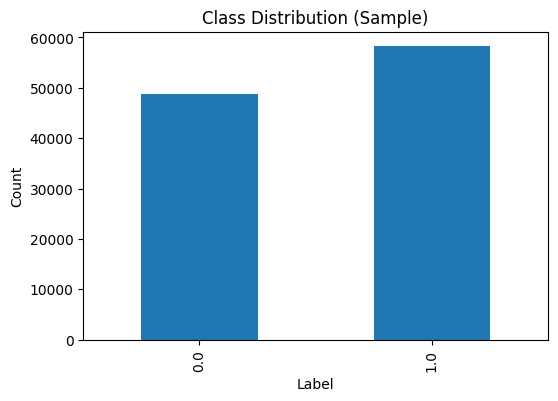

In [21]:
# Plot class distribution
class_counts = sample_pd["label"].value_counts().sort_index()

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution (Sample)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

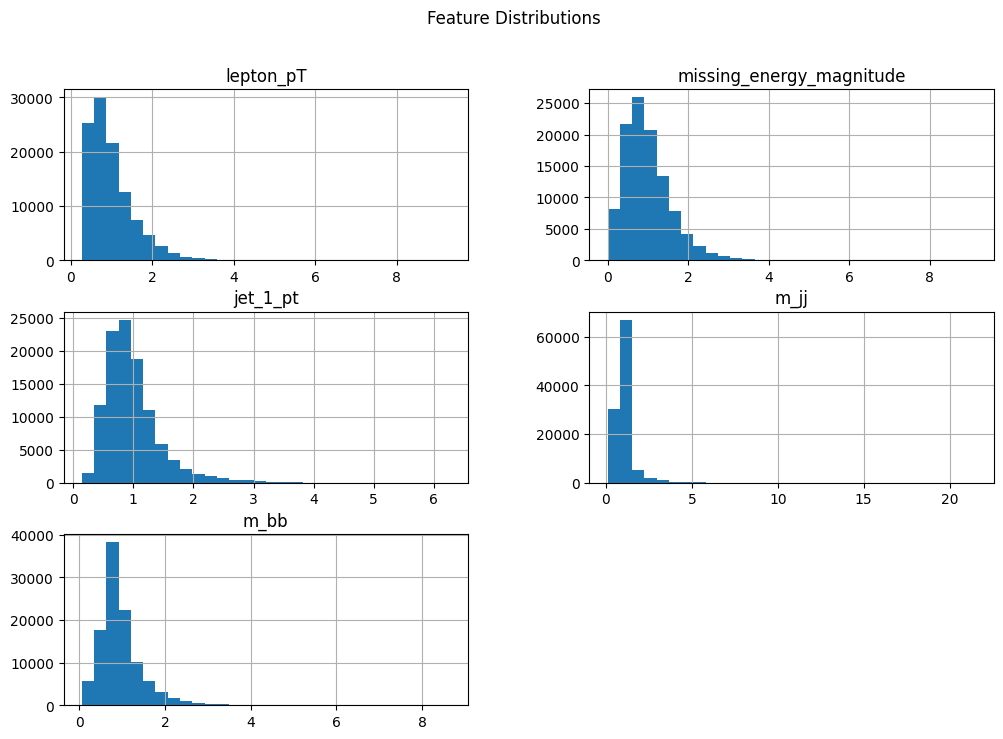

In [22]:
# Histograms for selected important features
selected_plot_features = [
    "lepton_pT", "missing_energy_magnitude", "jet_1_pt", "m_jj", "m_bb"
]

sample_pd[selected_plot_features].hist(figsize=(12,8), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

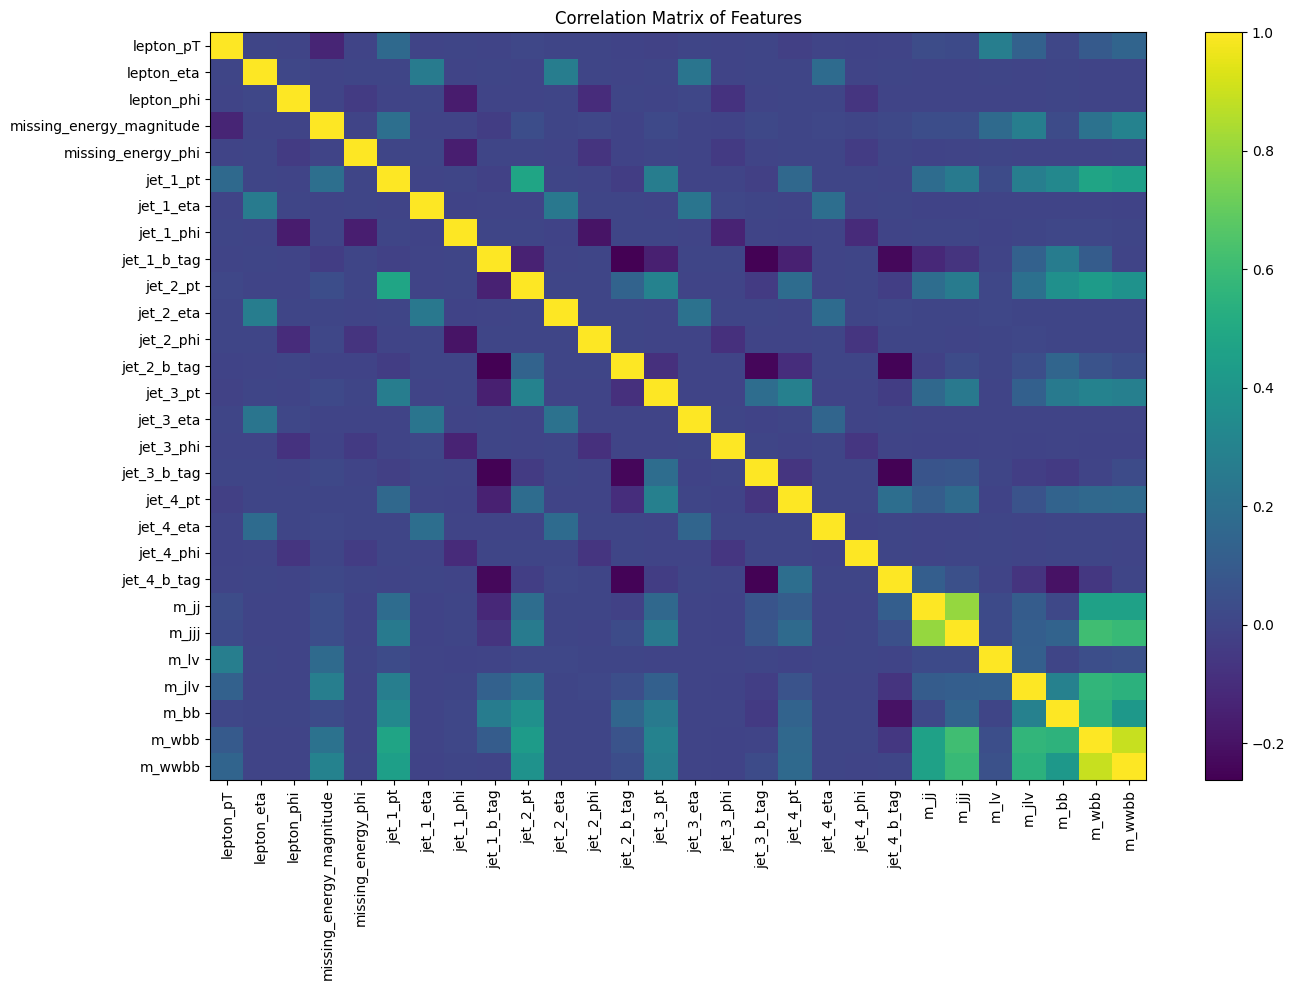

In [23]:
# Correlation matrix on sampled data
corr_matrix = sample_pd[all_features].corr()

plt.figure(figsize=(14,10))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.title("Correlation Matrix of Features")
plt.xticks(range(len(all_features)), all_features, rotation=90)
plt.yticks(range(len(all_features)), all_features)
plt.tight_layout()
plt.show()

In [24]:
# Summary statistics in Spark
df_clean.select(all_features).describe().show()

+-------+------------------+--------------------+--------------------+------------------------+--------------------+-------------------+--------------------+--------------------+------------------+-------------------+--------------------+--------------------+------------------+-------------------+--------------------+--------------------+------------------+-------------------+--------------------+--------------------+------------------+-------------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+
|summary|         lepton_pT|          lepton_eta|          lepton_phi|missing_energy_magnitude|  missing_energy_phi|           jet_1_pt|           jet_1_eta|           jet_1_phi|       jet_1_b_tag|           jet_2_pt|           jet_2_eta|           jet_2_phi|       jet_2_b_tag|           jet_3_pt|           jet_3_eta|           jet_3_phi|       jet_3_b_tag|           jet_4_pt|           jet_4_eta|           jet_4_phi| 

### EDA Observations

Write your findings here after running the cells. Example points:

- The dataset is relatively balanced between signal and background classes.
- Most variables are continuous and have different scales.
- Some features show skewed distributions.
- Correlation exists among several physics-derived variables.
- Feature scaling is likely beneficial for models such as Logistic Regression.
- Tree-based models may perform well without needing heavy transformation.

## 6. Train / Validation / Test Split

According to the HIGGS dataset documentation, the last **500,000 rows** are commonly used as the test set. We follow that convention here for a more standard evaluation setup. :contentReference[oaicite:1]{index=1}

The remaining data will be split into:
- training set
- validation set

In [25]:
# Safe and scalable split
train_df, val_df, test_df = sample_df.randomSplit([0.7, 0.15, 0.15], seed=42)

print("Train:", train_df.count())
print("Validation:", val_df.count())
print("Test:", test_df.count())

Train: 74891
Validation: 16168
Test: 16048


## 7. Model Selection

We compare multiple classification algorithms supported by Spark MLlib:

1. **Logistic Regression**
   - Good baseline model
   - Fast and scalable
   - Works well with standardized features

2. **Decision Tree**
   - Easy to interpret
   - Can model non-linear patterns

3. **Random Forest**
   - More robust than a single tree
   - Handles non-linearity and feature interactions well

4. **Gradient-Boosted Trees (GBT)**
   - Often stronger predictive performance
   - More computationally expensive

In [26]:
lr = LogisticRegression(
    featuresCol="features_scaled",
    labelCol="label",
    maxIter=20
)

dt = DecisionTreeClassifier(
    featuresCol="features_raw",
    labelCol="label",
    maxDepth=8
)

rf = RandomForestClassifier(
    featuresCol="features_raw",
    labelCol="label",
    numTrees=50,
    maxDepth=10,
    seed=42
)

gbt = GBTClassifier(
    featuresCol="features_raw",
    labelCol="label",
    maxIter=30,
    maxDepth=5,
    seed=42
)

## 8. Build Spark ML Pipelines

We use Spark ML Pipelines to create reproducible workflows that combine preprocessing and modeling into one structure.

In [27]:
lr_pipeline = Pipeline(stages=[assembler, scaler, lr])
dt_pipeline = Pipeline(stages=[assembler, dt])
rf_pipeline = Pipeline(stages=[assembler, rf])
gbt_pipeline = Pipeline(stages=[assembler, gbt])

## 9. Train Baseline Models

In [28]:
lr_model = lr_pipeline.fit(train_df)
dt_model = dt_pipeline.fit(train_df)
rf_model = rf_pipeline.fit(train_df)
gbt_model = gbt_pipeline.fit(train_df)

In [29]:
# Make validation predictions
lr_val_pred = lr_model.transform(val_df)
dt_val_pred = dt_model.transform(val_df)
rf_val_pred = rf_model.transform(val_df)
gbt_val_pred = gbt_model.transform(val_df)

## 10. Model Evaluation

We evaluate the models using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC AUC

Since this is a binary classification problem, ROC AUC is especially useful.

In [30]:
binary_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

In [31]:
def evaluate_model(pred_df, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_eval.evaluate(pred_df),
        "F1": f1_eval.evaluate(pred_df),
        "Precision": precision_eval.evaluate(pred_df),
        "Recall": recall_eval.evaluate(pred_df),
        "ROC_AUC": binary_eval.evaluate(pred_df)
    }

results = [
    evaluate_model(lr_val_pred, "Logistic Regression"),
    evaluate_model(dt_val_pred, "Decision Tree"),
    evaluate_model(rf_val_pred, "Random Forest"),
    evaluate_model(gbt_val_pred, "Gradient Boosted Trees")
]

results_df = pd.DataFrame(results)
results_df.sort_values(by="ROC_AUC", ascending=False)

,Model,Accuracy,F1,Precision,Recall,ROC_AUC
3,Gradient Boosted Trees,0.713199,0.712884,0.712721,0.713199,0.783897
2,Random Forest,0.708251,0.706880,0.707309,0.708251,0.779954
0,Logistic Regression,0.644545,0.636779,0.643762,0.644545,0.684380
1,Decision Tree,0.690252,0.689294,0.689230,0.690252,0.682019


In [32]:
results_df

,Model,Accuracy,F1,Precision,Recall,ROC_AUC
0,Logistic Regression,0.644545,0.636779,0.643762,0.644545,0.684380
1,Decision Tree,0.690252,0.689294,0.689230,0.690252,0.682019
2,Random Forest,0.708251,0.706880,0.707309,0.708251,0.779954
3,Gradient Boosted Trees,0.713199,0.712884,0.712721,0.713199,0.783897


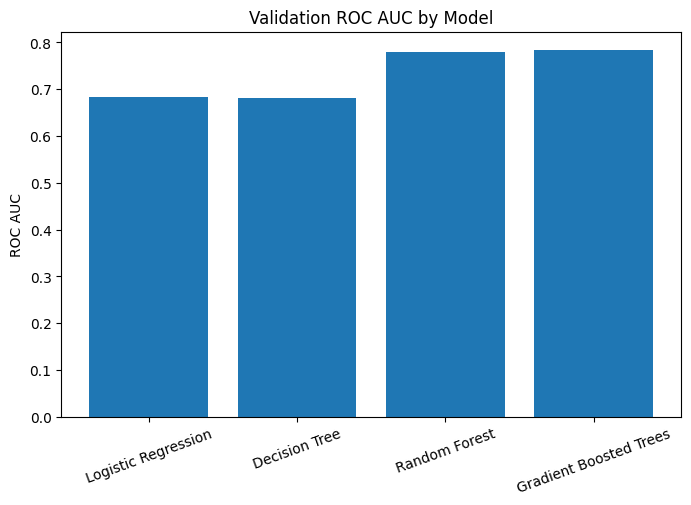

In [33]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["ROC_AUC"])
plt.title("Validation ROC AUC by Model")
plt.ylabel("ROC AUC")
plt.xticks(rotation=20)
plt.show()

### Baseline Model Comparison

Interpret the results here. Example:

- Logistic Regression provides a strong baseline and is computationally efficient.
- Decision Tree is interpretable but may underperform.
- Random Forest improves performance by reducing variance.
- GBT may provide the strongest predictive performance among tree-based models.
- The best model for final testing will be selected based on validation ROC AUC and overall metric balance.

## 11. Hyperparameter Tuning (Gradient Boosted Trees)

We tune the Gradient Boosted Trees (GBT) model, which showed the best performance during initial evaluation.

GBT is particularly effective for this dataset because it captures nonlinear relationships and feature interactions.

We use cross-validation with a parameter grid to identify the best combination of hyperparameters.

In [ ]:
from pyspark.ml.classification import GBTClassifier

gbt_tune = GBTClassifier(
    featuresCol="features_raw",
    labelCol="label",
    seed=42
)

In [ ]:
gbt_pipeline = Pipeline(stages=[assembler, gbt_tune])

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder

param_grid = ParamGridBuilder() \
    .addGrid(gbt_tune.maxIter, [30, 50]) \        # number of trees
    .addGrid(gbt_tune.maxDepth, [5, 6]) \         # tree depth
    .addGrid(gbt_tune.stepSize, [0.05, 0.1]) \    # learning rate
    .build()

In [ ]:
from pyspark.ml.tuning import CrossValidator

crossval = CrossValidator(
    estimator=gbt_pipeline,
    estimatorParamMaps=param_grid,
    evaluator=binary_eval,
    numFolds=3,     # keep 3 (not 5!)
    seed=42
)

In [ ]:
gbt_cv_model = crossval.fit(train_df)

In [ ]:
gbt_best_val_pred = gbt_cv_model.transform(val_df)

gbt_tuned_metrics = evaluate_model(gbt_best_val_pred, "Tuned GBT")
pd.DataFrame([gbt_tuned_metrics])

In [ ]:
best_gbt_model = gbt_cv_model.bestModel
print(best_gbt_model)

In [ ]:
final_model = gbt_cv_model

## 12. Optional Dimensionality Reduction with PCA

To satisfy the feature selection / dimensionality reduction requirement, we also test PCA-based dimensionality reduction.

This is especially useful for:
- reducing redundancy
- lowering dimensionality
- checking whether compressed features preserve predictive signal

In [ ]:
lr_pca = LogisticRegression(
    featuresCol="features_pca",
    labelCol="label",
    maxIter=20
)

pca_pipeline = Pipeline(stages=[assembler, scaler, pca, lr_pca])
pca_model = pca_pipeline.fit(train_df)
pca_val_pred = pca_model.transform(val_df)

pca_metrics = evaluate_model(pca_val_pred, "Logistic Regression + PCA")
pd.DataFrame([pca_metrics])

### Feature Engineering Discussion

You should discuss here:
- whether scaling improved linear models
- whether PCA reduced complexity
- whether high-level features improved classification power
- whether tree-based models handled raw features effectively

## 13. Final Model Selection

Based on validation performance, we now select the best model for final testing.

Replace `final_model` below with whichever performed best in your notebook:
- `lr_model`
- `dt_model`
- `rf_model`
- `gbt_model`
- `rf_cv_model`
- `pca_model`

In [ ]:
# Example: choose tuned random forest as final model
final_model = rf_cv_model

## 14. Test Set Evaluation

We now assess the selected model on the independent test set to estimate real-world generalization performance.

In [ ]:
test_pred = final_model.transform(test_df)
test_metrics = evaluate_model(test_pred, "Final Model on Test Set")
pd.DataFrame([test_metrics])

In [ ]:
test_metrics

## 15. Model Interpretation

In [ ]:
# If final model is Logistic Regression, inspect coefficients
# If final model is Random Forest or GBT, inspect feature importances

final_stage = final_model.bestModel.stages[-1] if hasattr(final_model, "bestModel") else final_model.stages[-1]

if hasattr(final_stage, "featureImportances"):
    importances = final_stage.featureImportances.toArray()
    feat_imp_df = pd.DataFrame({
        "Feature": all_features,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)
    
    feat_imp_df.head(15)
else:
    print("Feature importances not available for this model type.")

In [ ]:
if 'feat_imp_df' in locals():
    plt.figure(figsize=(10,6))
    plt.barh(feat_imp_df["Feature"].head(15)[::-1], feat_imp_df["Importance"].head(15)[::-1])
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.show()

### Interpretation Notes

Discuss:
- which features were most influential
- whether high-level physics features were important
- whether the model seems explainable enough for stakeholders
- possible reasons behind stronger or weaker performance

## 16. Overfitting / Underfitting Analysis

In [ ]:
# Evaluate final model on train and validation sets for comparison
train_pred = final_model.transform(train_df)
val_pred = final_model.transform(val_df)

train_auc = binary_eval.evaluate(train_pred)
val_auc = binary_eval.evaluate(val_pred)
test_auc = binary_eval.evaluate(test_pred)

print("Train ROC AUC:", train_auc)
print("Validation ROC AUC:", val_auc)
print("Test ROC AUC:", test_auc)

### Overfitting / Underfitting Discussion

Example interpretation:
- If training performance is much higher than validation/test, the model may be overfitting.
- If all scores are low, the model may be underfitting.
- If train, validation, and test scores are close, the model generalizes well.

## 17. Final Conclusion

This project implemented a scalable end-to-end machine learning workflow in Apache Spark for classifying Higgs boson collision events.

### Summary of Work
- Loaded the HIGGS dataset into Spark
- Cleaned and inspected the data
- Performed exploratory data analysis
- Built feature engineering and preprocessing pipelines
- Trained multiple machine learning models
- Compared models using standard classification metrics
- Tuned the best model
- Evaluated the final model on an independent test set

### Key Findings
- [Write your best model here]
- [Write your best ROC AUC / F1 / Accuracy here]
- [Mention whether PCA helped]
- [Mention the most important features]

### Recommendations
- Tree-based ensemble methods are strong candidates for this dataset.
- Spark ML pipelines provide a scalable framework for handling large datasets.
- Additional tuning and broader feature engineering may further improve performance.
- Future work could include XGBoost-on-Spark, deeper feature analysis, or class-threshold tuning.

## 18. References

1. HIGGS dataset, UCI Machine Learning Repository  
2. Kaggle mirror of HIGGS dataset  
3. Apache Spark MLlib documentation

In [ ]:
# Save evaluation results
results_df.to_csv("validation_model_comparison.csv", index=False)

In [ ]:
# Stop Spark session when done
# spark.stop()